# C-MAPSS: engine degradation and operating-condition changes

Explore all four subsets of NASA's simulated engine benchmark. Each row is
one observation per operating cycle, with 21 sensor values and three operating
settings. These are cycle-level trajectories, not raw high-frequency vibration.

[NASA source](https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/)
· [Dataset guide](../../pdmdata/cmapss/README.md)

Run `pdmdata.download("cmapss")` explicitly if needed. This notebook reads local
data and saves compact Matplotlib figures for GitHub. Unit IDs start at 1 and
are local to each subset and split; train unit 1 and test unit 1 are different
engines.


In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pdmdata").is_dir())
sys.path.insert(0, str(ROOT))
import polars as pl
import matplotlib.pyplot as plt
from IPython.display import display
import pdmdata
from pdmdata.cmapss import inventory, load, rul
from pdmdata.cmapss.loader import SENSOR_COLUMNS
from pdmdata.cmapss.viz import plot_waveforms, plot_operating_settings, plot_rul

summary = inventory()
display(summary)
print(f"Train/test trajectories: {summary['units'].sum():,}; cycle rows: {summary['rows'].sum():,}")


subset,split,units,rows,min_cycles,max_cycles,conditions,fault_modes
str,str,i64,i64,i64,i64,i64,i64
"""FD001""","""train""",100,20631,128,362,1,1
"""FD001""","""test""",100,13096,31,303,1,1
"""FD002""","""train""",260,53759,128,378,6,1
"""FD002""","""test""",259,33991,21,367,6,1
"""FD003""","""train""",100,24720,145,525,1,2
"""FD003""","""test""",100,16596,38,475,1,2
"""FD004""","""train""",249,61249,128,543,6,2
"""FD004""","""test""",248,41214,19,486,6,2


Train/test trajectories: 1,416; cycle rows: 265,256


## Subsets and source inventory

FD001/FD003 use one operating condition; FD002/FD004 use six. FD001/FD002
simulate HPC degradation; FD003/FD004 include HPC and fan degradation modes.
The files do not provide per-cycle fault-mode or fault-onset labels.

The bundled readme reverses the FD004 train/test counts: actual files contain
249 train and 248 test engines, with 248 test-end RUL targets. Inventory and
loading use the actual files. There are 709 train and 707 test trajectories.


## FD001: six sensor trajectories from one engine

Use `unit=1` to select one engine. Its observed training trajectory ends at
failure. The selected sensors retain their original values; no smoothing,
normalization, clipping, or healthy/faulty threshold is applied.


unit_number,cycle,sensor_2,sensor_11,RUL
u16,u32,f64,f64,u32
1,1,641.82,47.47,191
1,2,642.15,47.49,190
1,3,642.35,47.27,189
1,4,642.35,47.13,188
1,5,642.37,47.28,187


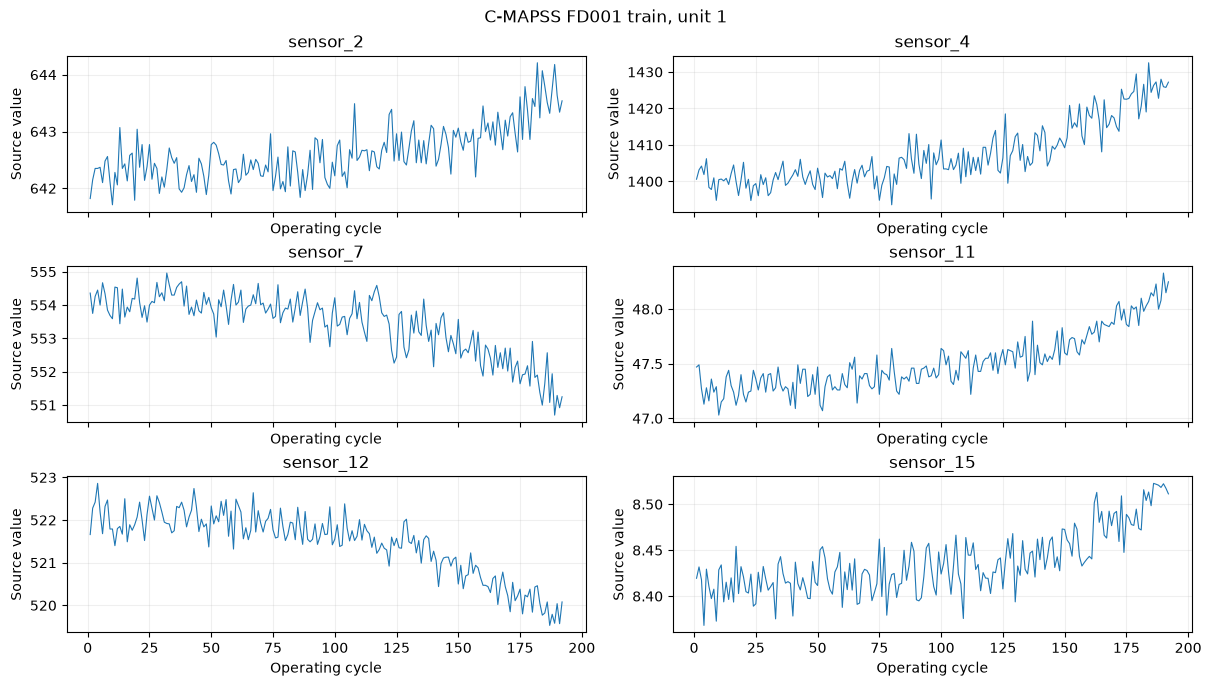

In [2]:
SUBSET = "FD001"
UNIT = 1
train_unit = load(SUBSET, "train", unit=UNIT, with_rul=True)
display(train_unit.select("unit_number", "cycle", "sensor_2", "sensor_11", "RUL").head())
waveforms = plot_waveforms(train_unit, subset=SUBSET)
assets = ROOT / "pdmdata/cmapss/assets"
assets.mkdir(parents=True, exist_ok=True)
waveforms.savefig(assets / "waveforms.png", dpi=100)
plt.show()


## Feature variability in the training split

Use the 21 sensors as candidate graph variables and keep operating settings as
separate context when that fits the model. Some sensors are constant or nearly
constant in a subset. Inspect variability using **training data only** before
choosing columns and fitting a scaler. Dropping exact constants alone does not
identify every numerically uninformative channel.


In [3]:
training = load(SUBSET, "train")
variability = pl.DataFrame({
    "sensor": SENSOR_COLUMNS,
    "unique_values": [training[c].n_unique() for c in SENSOR_COLUMNS],
    "standard_deviation": [training[c].std() for c in SENSOR_COLUMNS],
})
display(variability)
nonconstant = variability.filter(pl.col("unique_values") > 1)["sensor"].to_list()
X = train_unit.select(nonconstant)
print("Exact nonconstant sensor columns from FD001 training:", len(nonconstant))
print("Selected unit sensor-only shape:", X.shape)


sensor,unique_values,standard_deviation
str,i64,f64
"""sensor_1""",1,0.0
"""sensor_2""",310,0.500053
"""sensor_3""",3012,6.13115
"""sensor_4""",4051,9.000605
"""sensor_5""",1,0.0
…,…,…
"""sensor_17""",13,1.548763
"""sensor_18""",1,0.0
"""sensor_19""",1,0.0


Exact nonconstant sensor columns from FD001 training: 15
Selected unit sensor-only shape: (192, 15)


## FD002: multiple operating conditions change sensor values

The same six sensors can show much larger between-cycle jumps under changing
operating settings. The next figures use the first training engine of FD002,
first over its complete trajectory and then over its first 80 cycles. Do not
interpret every jump as a degradation event.


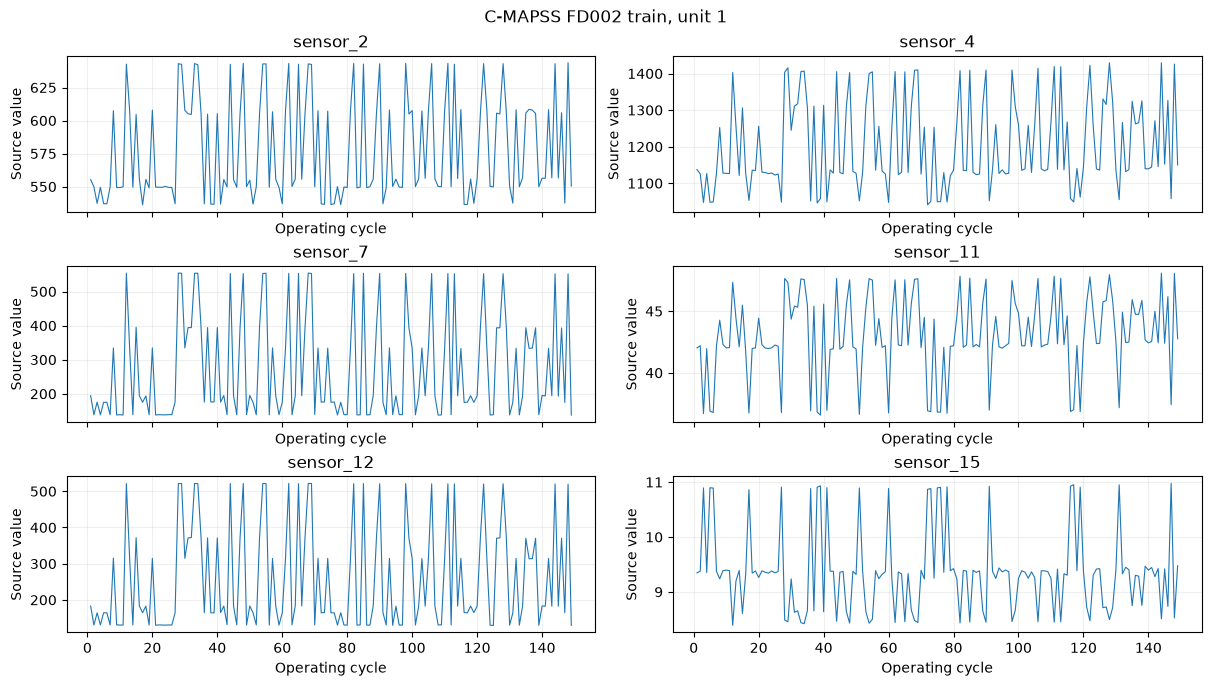

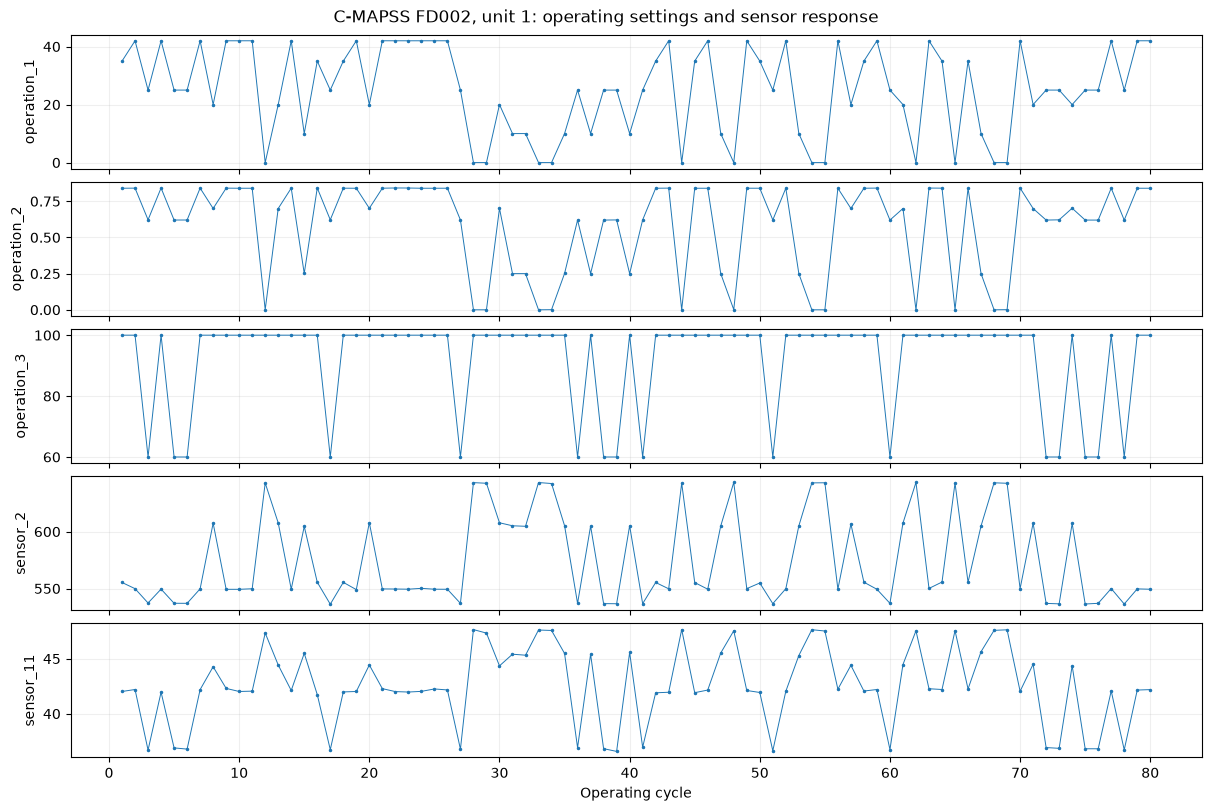

In [4]:
multiple_conditions = load("FD002", "train", unit=1)
condition_waveforms = plot_waveforms(multiple_conditions, subset="FD002")
plt.show()
settings = plot_operating_settings(multiple_conditions, subset="FD002", stop_cycle=80)
settings.savefig(assets / "operating_settings.png", dpi=100)
plt.show()


## Explicit RUL: train failure endpoints and official test offsets

`with_rul=True` adds uncapped RUL, measured in remaining operating cycles:

- Train: `max_observed_cycle - cycle`, ending at 0.
- Test: `max_observed_cycle - cycle + official_test_end_RUL`, ending at the
  supplied offset rather than 0.

`rul(subset)` returns the official offsets with explicit unit IDs. The legacy
`load(subset, split="rul")` API keeps its single RUL column in source row order.
Test targets are evaluation information: do not use them to fit the encoder,
select features, normalize inputs, or set segmentation thresholds.


unit_number,RUL
u16,u32
1,112
2,98
3,69
4,82
5,91


Train final RUL: 0
Test final RUL: 112


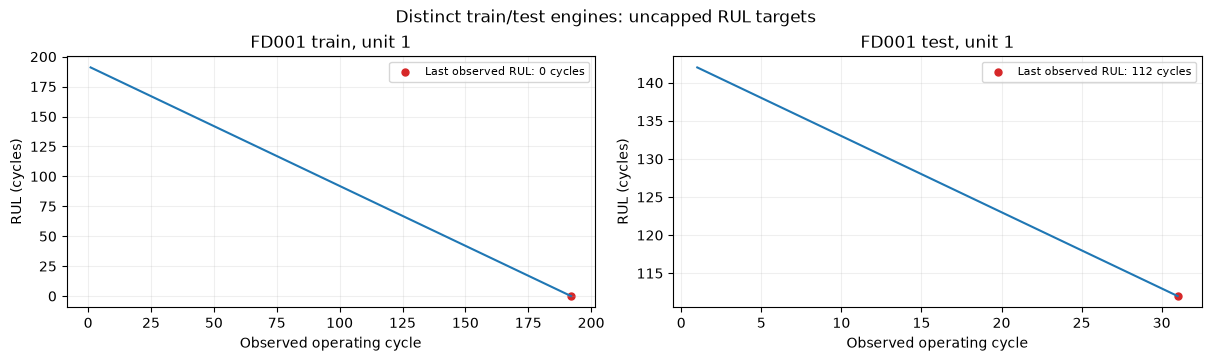

In [5]:
test_unit = load(SUBSET, "test", unit=UNIT, with_rul=True)
display(rul(SUBSET).head())
print("Train final RUL:", train_unit["RUL"][-1])
print("Test final RUL:", test_unit["RUL"][-1])
rul_figure = plot_rul(train_unit, test_unit, subset=SUBSET)
plt.show()


## Research implications

- Cycle is a discrete observation index; the files do not define an elapsed
  duration in seconds or a within-cycle waveform. Do not assign an Hz rate.
- Start with FD001 for degradation under one operating condition. FD002/FD004
  introduce operating-setting changes that affect sensor dependence as well as
  marginal signal levels. Separate operating-condition effects from degradation.
- The three recorded settings are observed covariates; an operating-state ID
  produced by clustering them would be a derived label, not supplied ground truth.
- There are no per-cycle fault-onset or segmentation labels. RUL supervision
  supports prognosis but is not a direct segmentation annotation.
- Uncapped RUL decreases from the start even during healthy operation; this
  target definition does not assume that damage began at the first observation.
- Keep engines separate and split validation by engine. Never place windows
  from one engine in both training and validation. Unit identity is the tuple
  `(subset, split, unit_number)`.
- `load()` retains all 26 source columns by default. Feature selection, scaling,
  interpolation, and RUL caps are modeling choices and are not applied silently.
- `verify()` checks complete engine/row counts, 26-column finite matrices,
  consecutive cycles, and one valid RUL offset per test engine. The ignored
  raw-data directory contains the verification report from preparation.

Citation: A. Saxena and K. Goebel (2008). *Turbofan Engine Degradation Simulation
Data Set*, NASA Prognostics Data Repository. Source-format details are from the
bundled readme and *Damage Propagation Modeling for Aircraft Engine
Run-to-Failure Simulation* (Saxena et al., 2008). Figures select source trajectories
and add axes; values are unchanged.
